# Customer Segmentation Analysis

**Objective:** Segment an e-commerce customer base by purchasing behaviour using RFM features and K-Means, then translate the segments into targeted marketing actions.

**Dataset:** *Online Retail.xlsx* — transaction data from 1 December 2010 through 9 December 2011.

This notebook covers data inspection and cleaning, descriptive statistics, RFM feature engineering, scaling, Elbow Method selection of K, cluster visualisation, profiling, segment sizing, and marketing recommendations.

In [20]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
RANDOM_STATE = 42

## 1. Load and inspect the data

The path below first uses the supplied workbook location, then falls back to a workbook placed beside this notebook. This keeps the analysis easy to rerun on another machine.

In [18]:
candidate_paths = [
    Path("C:/Users/hilva/Downloads/Online Retail.xlsx"),
    Path("Online Retail.xlsx"),
]
data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Place 'Online Retail.xlsx' beside the notebook or update candidate_paths.")

raw = pd.read_excel(data_path)
print(f"Loaded: {data_path}")
print(f"Raw shape: {raw.shape[0]:,} rows × {raw.shape[1]} columns")
display(raw.head())

Loaded: C:\Users\hilva\Downloads\Online Retail.xlsx
Raw shape: 541,909 rows × 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [19]:
structure = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing_count": raw.isna().sum(),
    "missing_pct": raw.isna().mean().mul(100),
    "unique_values": raw.nunique(dropna=True),
})
display(structure)
display(raw.describe(include="all").T)

,dtype,missing_count,missing_pct,unique_values
InvoiceNo,object,0,0.00,25900
StockCode,object,0,0.00,4070
Description,object,1454,0.27,4223
Quantity,int64,0,0.00,722
InvoiceDate,datetime64[us],0,0.00,23260
UnitPrice,float64,0,0.00,1630
CustomerID,float64,135080,24.93,4372
Country,str,0,0.00,38


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,"541,909.00","25,900.00","573,585.00","1,114.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,"541,909.00",NaN,NaN,NaN,9.55,"-80,995.00",1.00,3.00,10.00,"80,995.00",218.08
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,"541,909.00",NaN,NaN,NaN,4.61,"-11,062.06",1.25,2.08,4.13,"38,970.00",96.76
CustomerID,"406,829.00",NaN,NaN,NaN,"15,287.69","12,346.00","13,953.00","15,152.00","16,791.00","18,287.00","1,713.60"
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Clean inconsistent and incomplete records

Cleaning rules:

- Remove exact duplicate rows.
- Exclude rows without a `CustomerID` because customer-level behaviour cannot be assigned.
- Exclude cancellation invoices (`InvoiceNo` begins with **C**), non-positive quantities, and non-positive unit prices. These are returns, reversals, adjustments, or invalid sales rather than completed purchases.
- Convert identifiers to stable string types and dates/numbers to appropriate types.
- Missing descriptions are reported but do not block RFM calculations because product descriptions are not clustering inputs.

In [21]:
df = raw.copy()
audit_before = len(df)
duplicate_rows = int(df.duplicated().sum())
missing_customer = int(df["CustomerID"].isna().sum())

df = df.drop_duplicates().copy()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")
df["InvoiceNo"] = df["InvoiceNo"].astype(str).str.strip()

cancelled = df["InvoiceNo"].str.upper().str.startswith("C")
invalid_sale = (
    df["CustomerID"].isna()
    | df["InvoiceDate"].isna()
    | (df["Quantity"] <= 0)
    | (df["UnitPrice"] <= 0)
    | cancelled
)
clean = df.loc[~invalid_sale].copy()
clean["CustomerID"] = clean["CustomerID"].astype("int64").astype(str)
clean["LineTotal"] = clean["Quantity"] * clean["UnitPrice"]

cleaning_audit = pd.DataFrame({
    "Measure": [
        "Raw rows", "Exact duplicate rows", "Rows missing CustomerID (raw)",
        "Cancellation / return / invalid / anonymous rows removed after de-duplication",
        "Clean sales rows", "Retained share of raw rows"
    ],
    "Value": [
        audit_before, duplicate_rows, missing_customer,
        int(invalid_sale.sum()), len(clean), len(clean) / audit_before
    ]
})
display(cleaning_audit)
print(f"Clean date range: {clean['InvoiceDate'].min():%Y-%m-%d} to {clean['InvoiceDate'].max():%Y-%m-%d}")
print(f"Customers retained: {clean['CustomerID'].nunique():,}")

,Measure,Value
0,Raw rows,"541,909.00"
1,Exact duplicate rows,"5,268.00"
2,Rows missing CustomerID (raw),"135,080.00"
3,Cancellation / return / invalid / anonymous ro...,"143,949.00"
4,Clean sales rows,"392,692.00"
5,Retained share of raw rows,0.72


Clean date range: 2010-12-01 to 2011-12-09
Customers retained: 4,338


## 3. Customer-level descriptive statistics and RFM features

The clustering features are:

- **Recency:** days since the customer's most recent purchase (lower is better).
- **Frequency:** number of distinct completed invoices.
- **Monetary / observed CLV:** total completed-purchase revenue in the observation window.

We also calculate **average purchase value** (`Monetary / Frequency`) and customer **lifetime span** for descriptive profiling. Monetary is described as *observed CLV* to distinguish it from a predictive future-lifetime model.

In [22]:
reference_date = clean["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)

customer = clean.groupby("CustomerID").agg(
    FirstPurchase=("InvoiceDate", "min"),
    LastPurchase=("InvoiceDate", "max"),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("LineTotal", "sum"),
    ItemsPurchased=("Quantity", "sum"),
)
customer["Recency"] = (reference_date - customer["LastPurchase"].dt.normalize()).dt.days
customer["LifetimeDays"] = (
    customer["LastPurchase"].dt.normalize() - customer["FirstPurchase"].dt.normalize()
).dt.days + 1
customer["AveragePurchaseValue"] = customer["Monetary"] / customer["Frequency"]
customer["ObservedCLV"] = customer["Monetary"]

customer = customer[[
    "Recency", "Frequency", "Monetary", "AveragePurchaseValue",
    "ObservedCLV", "LifetimeDays", "ItemsPurchased", "FirstPurchase", "LastPurchase"
]]
display(customer.head())

,Recency,Frequency,Monetary,AveragePurchaseValue,ObservedCLV,LifetimeDays,ItemsPurchased,FirstPurchase,LastPurchase
CustomerID,,,,,,,,,
12346,326,1,"77,183.60","77,183.60","77,183.60",1,74215,2011-01-18 10:01:00,2011-01-18 10:01:00
12347,3,7,"4,310.00",615.71,"4,310.00",366,2458,2010-12-07 14:57:00,2011-12-07 15:52:00
12348,76,4,"1,797.24",449.31,"1,797.24",284,2341,2010-12-16 19:09:00,2011-09-25 13:13:00
12349,19,1,"1,757.55","1,757.55","1,757.55",1,631,2011-11-21 09:51:00,2011-11-21 09:51:00
12350,311,1,334.40,334.40,334.40,1,197,2011-02-02 16:01:00,2011-02-02 16:01:00


In [23]:
descriptive_summary = customer[[
    "AveragePurchaseValue", "Frequency", "ObservedCLV", "Recency", "LifetimeDays"
]].describe(percentiles=[.25, .5, .75, .9, .95]).T
display(descriptive_summary)

key_metrics = pd.Series({
    "Customers": len(customer),
    "Average purchase value (mean customer)": customer["AveragePurchaseValue"].mean(),
    "Purchase frequency (mean invoices/customer)": customer["Frequency"].mean(),
    "Observed CLV (mean revenue/customer)": customer["ObservedCLV"].mean(),
    "Observed CLV (median revenue/customer)": customer["ObservedCLV"].median(),
}, name="Value").to_frame()
display(key_metrics)

,count,mean,std,min,25%,50%,75%,90%,95%,max
AveragePurchaseValue,"4,338.00",417.65,"1,796.51",3.45,177.87,291.94,428.28,659.74,936.33,"84,236.25"
Frequency,"4,338.00",4.27,7.70,1.00,1.00,2.00,5.00,9.00,13.00,209.00
ObservedCLV,"4,338.00","2,048.69","8,985.23",3.75,306.48,668.57,"1,660.60","3,640.84","5,790.00","280,206.02"
Recency,"4,338.00",93.06,100.01,1.00,18.00,51.00,142.75,263.30,312.00,374.00
LifetimeDays,"4,338.00",131.77,132.21,1.00,1.00,94.00,253.00,341.00,358.00,374.00


,Value
Customers,"4,338.00"
Average purchase value (mean customer),417.65
Purchase frequency (mean invoices/customer),4.27
Observed CLV (mean revenue/customer),"2,048.69"
Observed CLV (median revenue/customer),668.57


## 4. Prepare features for clustering

RFM values are strongly right-skewed. To prevent a handful of unusually large accounts from dominating Euclidean distance, we cap each feature at its 1st and 99th percentiles, apply `log1p`, and then standardise with `StandardScaler`. Cluster profiles later use the original, uncapped business units.

In [24]:
feature_cols = ["Recency", "Frequency", "Monetary"]
X_business = customer[feature_cols].copy()

lower = X_business.quantile(0.01)
upper = X_business.quantile(0.99)
X_winsor = X_business.clip(lower=lower, upper=upper, axis=1)
X_log = np.log1p(X_winsor)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
X_scaled = pd.DataFrame(X_scaled, index=customer.index, columns=feature_cols)

display(pd.DataFrame({"cap_1st_percentile": lower, "cap_99th_percentile": upper}))
display(X_scaled.describe().loc[["mean", "std", "min", "max"]])

,cap_1st_percentile,cap_99th_percentile
Recency,2.00,369.63
Frequency,1.00,30.00
Monetary,52.20,"19,780.49"


,Recency,Frequency,Monetary
mean,0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-2.13,-0.97,-2.15
max,1.58,3.15,2.72


## 5. Elbow Method: determine the number of clusters

K-Means is fitted for `K = 2…10`. Inertia always falls as K increases, so the elbow is identified using the maximum perpendicular distance from the inertia curve to the straight line joining its endpoints. Silhouette scores are shown as a secondary diagnostic, not as the selection rule.

,K,Inertia,Silhouette,KneeDistance
0,2,6312.535581,0.435888,0.000000
1,3,4699.725476,0.338161,0.167910
2,4,3748.172000,0.336473,0.230737
3,5,3115.823345,0.319031,0.242838
4,6,2680.387065,0.316363,0.223646
5,7,2390.014385,0.309505,0.181402
6,8,2185.289316,0.306772,0.125548
7,9,2013.086176,0.285669,0.064525
8,10,1862.920446,0.283890,0.000000


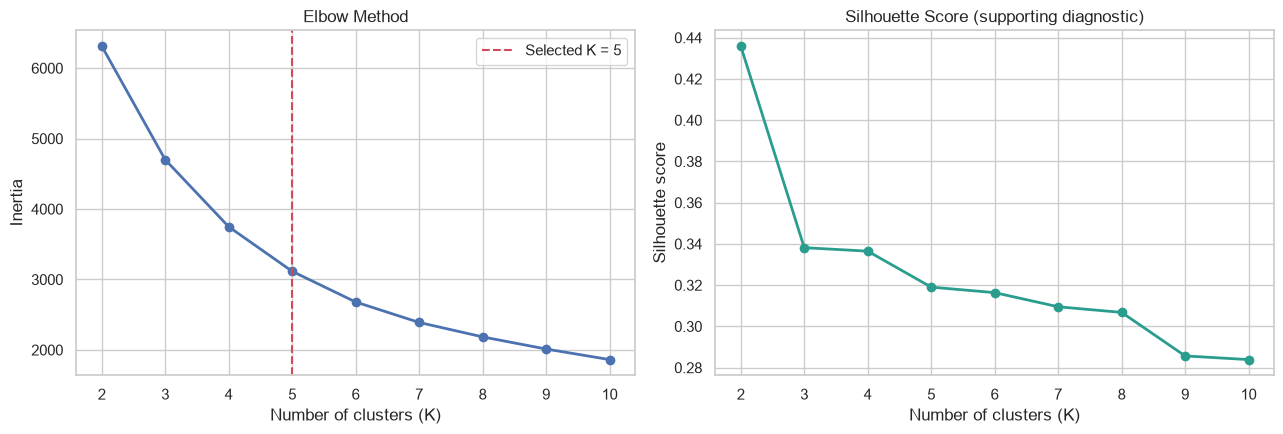

Selected K = 5 using the geometric elbow criterion.


In [25]:
k_values = list(range(2, 11))
inertias, silhouettes = [], []
for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Geometric knee: greatest distance from the line between first and last points.
points = np.column_stack([k_values, inertias]).astype(float)
scaled_points = (points - points.min(axis=0)) / (points.max(axis=0) - points.min(axis=0))
start, end = scaled_points[0], scaled_points[-1]
line = end - start
offsets = scaled_points - start
distances = np.abs(line[0] * offsets[:, 1] - line[1] * offsets[:, 0]) / np.linalg.norm(line)
optimal_k = int(k_values[int(np.argmax(distances))])

elbow_results = pd.DataFrame({
    "K": k_values, "Inertia": inertias, "Silhouette": silhouettes, "KneeDistance": distances
})
display(elbow_results.style.highlight_max(subset=["KneeDistance"], color="#b7e4c7"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(k_values, inertias, marker="o", linewidth=2)
axes[0].axvline(optimal_k, color="#d1495b", linestyle="--", label=f"Selected K = {optimal_k}")
axes[0].set(title="Elbow Method", xlabel="Number of clusters (K)", ylabel="Inertia")
axes[0].legend()
axes[1].plot(k_values, silhouettes, marker="o", color="#2a9d8f", linewidth=2)
axes[1].set(title="Silhouette Score (supporting diagnostic)", xlabel="Number of clusters (K)", ylabel="Silhouette score")
plt.tight_layout()
plt.show()
print(f"Selected K = {optimal_k} using the geometric elbow criterion.")

## 6. Fit the final K-Means model

In [26]:
final_model = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=50)
customer["Cluster"] = final_model.fit_predict(X_scaled)

profile = customer.groupby("Cluster").agg(
    Customers=("Cluster", "size"),
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    MedianMonetary=("Monetary", "median"),
    AveragePurchaseValue=("AveragePurchaseValue", "mean"),
    LifetimeDays=("LifetimeDays", "mean"),
)
profile["CustomerSharePct"] = profile["Customers"] / len(customer) * 100
profile["RevenueSharePct"] = customer.groupby("Cluster")["Monetary"].sum() / customer["Monetary"].sum() * 100
display(profile.sort_values("Monetary", ascending=False))

,Customers,Recency,Frequency,Monetary,MedianMonetary,AveragePurchaseValue,LifetimeDays,CustomerSharePct,RevenueSharePct
Cluster,,,,,,,,,
1,433,14.37,18.27,"11,355.93","5,398.30",573.86,323.02,9.98,55.33
4,960,20.79,5.28,"2,074.01","1,600.56",482.52,231.82,22.13,22.40
0,978,113.35,2.95,"1,403.69",954.50,627.47,137.48,22.54,15.45
2,860,30.42,1.56,366.85,335.44,260.24,67.37,19.82,3.55
3,1107,217.25,1.20,262.64,234.60,237.19,15.19,25.52,3.27


## 7. Assign interpretable segment names

Names are assigned from cluster behaviour rather than arbitrary cluster numbers. The highest combined value cluster becomes **Champions**; the stalest cluster becomes **At Risk**; the strongest remaining frequency cluster becomes **Loyal**. Any additional clusters are labelled **Promising** or **Occasional** according to recency.

In [27]:
rank = profile.copy()
rank["ValueScore"] = (
    rank["Frequency"].rank(pct=True)
    + rank["Monetary"].rank(pct=True)
    + (-rank["Recency"]).rank(pct=True)
)

available = set(profile.index)
name_map = {}
champions = rank["ValueScore"].idxmax()
name_map[champions] = "Champions"
available.remove(champions)

if available:
    at_risk = profile.loc[list(available), "Recency"].idxmax()
    name_map[at_risk] = "At Risk"
    available.remove(at_risk)
if available:
    loyal = profile.loc[list(available), "Frequency"].idxmax()
    name_map[loyal] = "Loyal Customers"
    available.remove(loyal)

remaining = sorted(available, key=lambda c: profile.loc[c, "Recency"])
remaining_names = ["Promising", "Occasional", "Needs Attention", "New / Low Value", "Other"]
for cluster_id, segment_name in zip(remaining, remaining_names):
    name_map[cluster_id] = segment_name

customer["Segment"] = customer["Cluster"].map(name_map)
profile["Segment"] = profile.index.map(name_map)
display(profile.set_index("Segment").sort_values("Monetary", ascending=False))

,Customers,Recency,Frequency,Monetary,MedianMonetary,AveragePurchaseValue,LifetimeDays,CustomerSharePct,RevenueSharePct
Segment,,,,,,,,,
Champions,433,14.37,18.27,"11,355.93","5,398.30",573.86,323.02,9.98,55.33
Loyal Customers,960,20.79,5.28,"2,074.01","1,600.56",482.52,231.82,22.13,22.40
Occasional,978,113.35,2.95,"1,403.69",954.50,627.47,137.48,22.54,15.45
Promising,860,30.42,1.56,366.85,335.44,260.24,67.37,19.82,3.55
At Risk,1107,217.25,1.20,262.64,234.60,237.19,15.19,25.52,3.27


## 8. Visualise the customer clusters

The first chart contrasts engagement and order frequency; the second contrasts order frequency and customer value. Axes use logarithmic scales because retail behaviour is highly skewed.

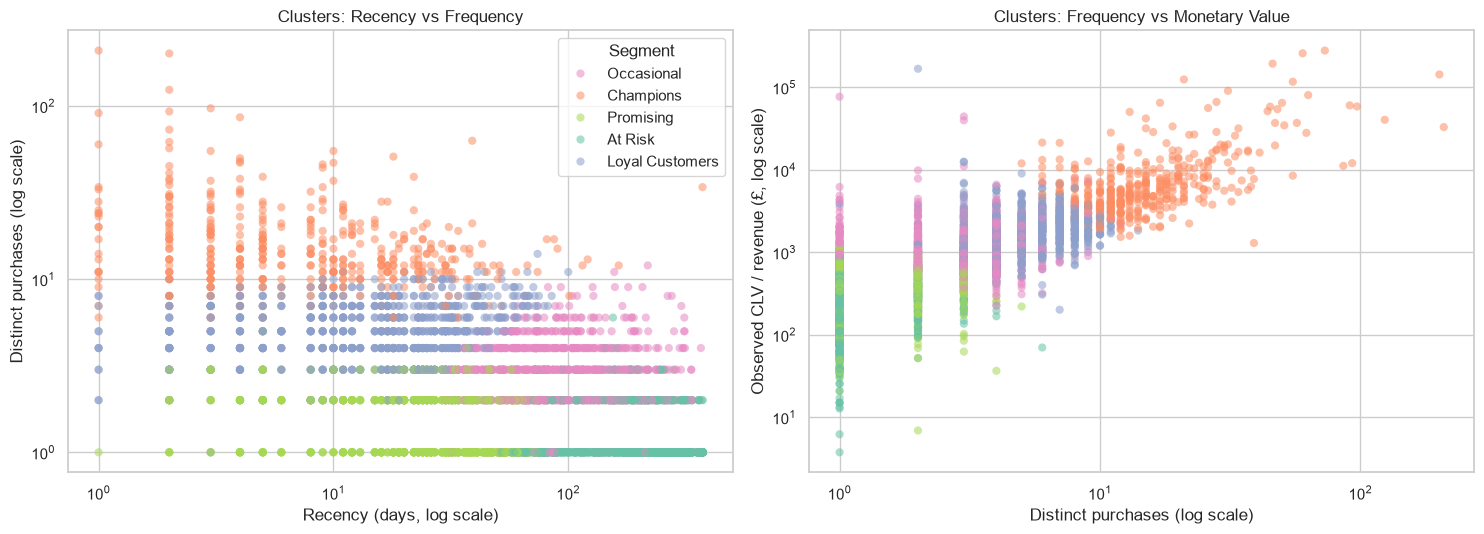

In [28]:
plot_df = customer.reset_index()
segment_order = profile.sort_values("ValueScore" if "ValueScore" in profile.columns else "Monetary", ascending=False).index if False else None
palette = dict(zip(sorted(plot_df["Segment"].unique()), sns.color_palette("Set2", n_colors=optimal_k)))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.scatterplot(data=plot_df, x="Recency", y="Frequency", hue="Segment", palette=palette,
                alpha=.55, s=35, linewidth=0, ax=axes[0])
axes[0].set(xscale="log", yscale="log", title="Clusters: Recency vs Frequency",
            xlabel="Recency (days, log scale)", ylabel="Distinct purchases (log scale)")

sns.scatterplot(data=plot_df, x="Frequency", y="Monetary", hue="Segment", palette=palette,
                alpha=.55, s=35, linewidth=0, ax=axes[1], legend=False)
axes[1].set(xscale="log", yscale="log", title="Clusters: Frequency vs Monetary Value",
            xlabel="Distinct purchases (log scale)", ylabel="Observed CLV / revenue (£, log scale)")
plt.tight_layout()
plt.show()

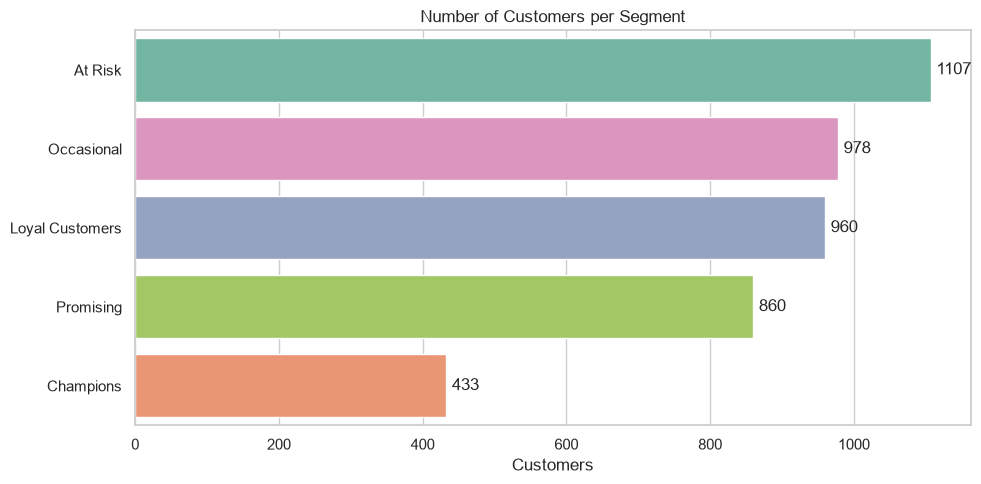

In [29]:
count_order = customer["Segment"].value_counts().index
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=customer, y="Segment", order=count_order, palette=palette)
ax.set(title="Number of Customers per Segment", xlabel="Customers", ylabel="")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=4)
plt.tight_layout()
plt.show()

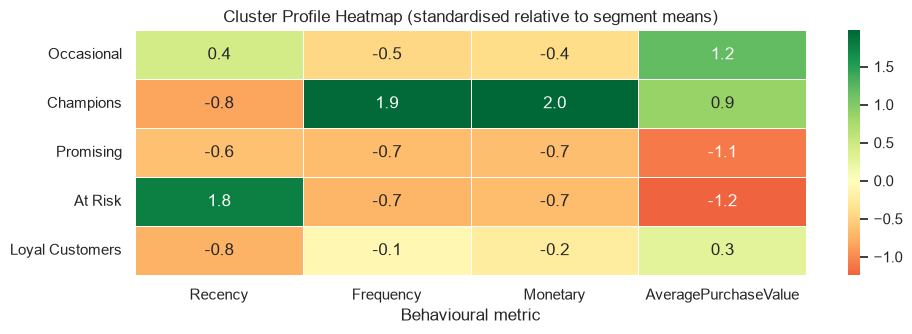

In [30]:
heat = profile.set_index("Segment")[["Recency", "Frequency", "Monetary", "AveragePurchaseValue"]]
heat_z = (heat - heat.mean()) / heat.std(ddof=0)
plt.figure(figsize=(10, max(3.5, optimal_k * .7)))
sns.heatmap(heat_z, annot=True, fmt=".1f", cmap="RdYlGn", center=0, linewidths=.5)
plt.title("Cluster Profile Heatmap (standardised relative to segment means)")
plt.xlabel("Behavioural metric")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 9. Segment profiles and recommended marketing actions

In [31]:
action_library = {
    "Champions": "Protect and reward: VIP access, early product launches, referral rewards, and personalised cross-sell. Avoid indiscriminate discounting.",
    "Loyal Customers": "Deepen the relationship: loyalty tiers, replenishment reminders, bundles, subscriptions, and category-based recommendations.",
    "Promising": "Build purchase habit: welcome journeys, a time-limited second/next-purchase incentive, social proof, and relevant product education.",
    "Occasional": "Increase frequency: seasonal reminders, low-friction bundles, free-shipping thresholds, and browse/purchase-triggered campaigns.",
    "At Risk": "Win back selectively: urgency-led reactivation, personalised reminders based on prior categories, and a controlled incentive; suppress after repeated non-response.",
    "Needs Attention": "Diagnose friction: targeted survey, service recovery where relevant, and narrowly tailored comeback offers.",
    "New / Low Value": "Nurture economically: automated onboarding, best-seller discovery, trust signals, and low-cost digital retargeting.",
    "Other": "Test differentiated messages and monitor response before committing substantial promotional budget.",
}

segment_profile = profile.reset_index().set_index("Segment").drop(columns=["Cluster"], errors="ignore")
segment_profile["Customer Type"] = [
    (
        f"{r['Customers']:.0f} customers ({r['CustomerSharePct']:.1f}%); "
        f"average recency {r['Recency']:.0f} days, frequency {r['Frequency']:.1f}, "
        f"and observed CLV £{r['Monetary']:,.0f}."
    ) for _, r in segment_profile.iterrows()
]
segment_profile["Recommended Marketing Action"] = [action_library.get(s, action_library["Other"]) for s in segment_profile.index]
display(segment_profile[[
    "Customers", "CustomerSharePct", "RevenueSharePct", "Recency", "Frequency",
    "Monetary", "AveragePurchaseValue", "Customer Type", "Recommended Marketing Action"
]].sort_values("Monetary", ascending=False))

,Customers,CustomerSharePct,RevenueSharePct,Recency,Frequency,Monetary,AveragePurchaseValue,Customer Type,Recommended Marketing Action
Segment,,,,,,,,,
Champions,433,9.98,55.33,14.37,18.27,"11,355.93",573.86,433 customers (10.0%); average recency 14 days...,"Protect and reward: VIP access, early product ..."
Loyal Customers,960,22.13,22.40,20.79,5.28,"2,074.01",482.52,960 customers (22.1%); average recency 21 days...,"Deepen the relationship: loyalty tiers, replen..."
Occasional,978,22.54,15.45,113.35,2.95,"1,403.69",627.47,978 customers (22.5%); average recency 113 day...,"Increase frequency: seasonal reminders, low-fr..."
Promising,860,19.82,3.55,30.42,1.56,366.85,260.24,860 customers (19.8%); average recency 30 days...,"Build purchase habit: welcome journeys, a time..."
At Risk,1107,25.52,3.27,217.25,1.20,262.64,237.19,1107 customers (25.5%); average recency 217 da...,Win back selectively: urgency-led reactivation...


In [32]:
display(Markdown("### Executive insights"))
top_value = segment_profile["Monetary"].idxmax()
largest = segment_profile["Customers"].idxmax()
stalest = segment_profile["Recency"].idxmax()
top_revenue_share = segment_profile.loc[top_value, "RevenueSharePct"]
print(f"• {top_value} is the highest-value segment and contributes {top_revenue_share:.1f}% of retained revenue.")
print(f"• {largest} is the largest segment ({segment_profile.loc[largest, 'Customers']:.0f} customers), so scalable automation matters most here.")
print(f"• {stalest} has the longest average recency ({segment_profile.loc[stalest, 'Recency']:.0f} days) and is the clearest reactivation target.")
print("• Use holdout groups and measure incremental revenue, margin, repeat purchase rate, and unsubscribe rate—not campaign response alone.")
print("• Re-score customers regularly (for example monthly) because segment membership changes as new purchases arrive.")

### Executive insights

• Champions is the highest-value segment and contributes 55.3% of retained revenue.
• At Risk is the largest segment (1107 customers), so scalable automation matters most here.
• At Risk has the longest average recency (217 days) and is the clearest reactivation target.
• Use holdout groups and measure incremental revenue, margin, repeat purchase rate, and unsubscribe rate—not campaign response alone.
• Re-score customers regularly (for example monthly) because segment membership changes as new purchases arrive.


## 10. Limitations and next steps

- Returns/cancellations are excluded from behavioural features; a follow-up model should separately study return propensity and net profitability.
- Monetary value is observed historical revenue, not a predictive lifetime-value forecast and not profit.
- K-Means assumes roughly spherical groups and is sensitive to feature transformations. Compare stability over time and consider hierarchical clustering or Gaussian mixtures as challengers.
- Geography, product preferences, acquisition channel, margin, and campaign response could enrich targeting once reliable fields are available.
- Segment labels are analytical summaries—not claims about individual intent. Validate each marketing treatment with controlled experiments.